# 회고

- (참고) 뒷부분에 모델 성능 개선 코드가 있습니다. 거기서부터 보면 됩니다 !!

- 성능이 너무 낮아서, train 이미지와 test 이미지를 뽑아서 비교해보니 피부 색 차이와 화면 밝기 등의 차이가 있어서, GRayScale 또는 데이터 증강 방법을 적용하여 진행하려고 했음,
- 하지만, 애초에 이미지가 28x28 크기로 resize 되어 화질이 낮아지고, 흐릿해져 다른 방식을 적용해도 성능이 개선되지 않았다.
- 그래서 나중에는, 이미지를 28x28 크기가 아니라, 좀 더 늘린 64x64나 128x128 사이즈로 변환하여, 이미지 화질을 개선하여 다시 진행해보고 싶다.

In [1]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

2.6.0
1.22.2


In [2]:
from PIL import Image 
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [3]:
def resize_images(img_path):
	images=glob.glob(img_path + "/*.jpg")  
    
	print(len(images), " images to be resized.")

    # 파일마다 모두 28x28 사이즈로 바꾸어 저장합니다.
	target_size=(28,28)
	for img in images:
		old_img=Image.open(img)
		new_img=old_img.resize(target_size,Image.ANTIALIAS)
		new_img.save(img, "JPEG")
    
	print(len(images), " images resized.")
	
# 가위 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/scissor"
resize_images(image_dir_path)

print("가위 이미지 resize 완료!")

100  images to be resized.
100  images resized.
가위 이미지 resize 완료!


In [4]:
# 바위 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/rock"

# 파일마다 모두 28x28 사이즈로 바꾸어 저장합니다.
resize_images(image_dir_path)
print("바위 이미지 resize 완료!")

100  images to be resized.
100  images resized.
바위 이미지 resize 완료!


In [6]:
# 보 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/paper"

# 파일마다 모두 28x28 사이즈로 바꾸어 저장합니다.
resize_images(image_dir_path)
print("보 이미지 resize 완료!")

100  images to be resized.
100  images resized.
보 이미지 resize 완료!


In [7]:
import numpy as np

def load_data(img_path, number_of_data=300):  # 가위바위보 이미지 개수 총합에 주의하세요.
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=28
    color=3
    #이미지 데이터와 라벨(가위 : 0, 바위 : 1, 보 : 2) 데이터를 담을 행렬(matrix) 영역을 생성합니다.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=0   # 가위 : 0
        idx=idx+1

    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=1   # 바위 : 1
        idx=idx+1  
    
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=2   # 보 : 2
        idx=idx+1
        
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper"
(x_train, y_train)=load_data(image_dir_path)
x_train_norm = x_train/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

학습데이터(x_train)의 이미지 개수는 300 입니다.
x_train shape: (300, 28, 28, 3)
y_train shape: (300,)


라벨:  0


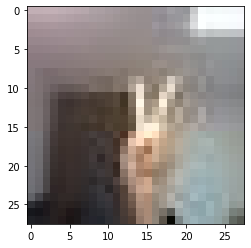

In [8]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
print('라벨: ', y_train[0])

# 딥러닝 네트워크 설계하기

In [18]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# model을 직접 만들어 보세요.
# Hint! model의 입력/출력부에 특히 유의해 주세요. 가위바위보 데이터셋은 MNIST 데이터셋과 어떤 점이 달라졌나요?
n_channel_1=16
n_channel_2=32
n_dense=32
n_train_epoch=10

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 26, 26, 16)        448       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 13, 13, 16)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 11, 11, 32)        4640      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 5, 5, 32)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 800)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 32)                25632     
_________________________________________________________________
dense_3 (Dense)              (None, 3)                

In [19]:
# model을 학습시키는 코드를 직접 작성해 보세요. 
# Hint! model.compile()과 model.fit()을 사용해 봅시다.

model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

# 모델 훈련
model.fit(x_train_norm, y_train, epochs=n_train_epoch)

Epoch 1/10
10/10 [==============================] - 1s 25ms/step - loss: 1.0590 - accuracy: 0.4767
Epoch 2/10
10/10 [==============================] - 0s 23ms/step - loss: 0.8603 - accuracy: 0.8700
Epoch 3/10
10/10 [==============================] - 0s 23ms/step - loss: 0.6147 - accuracy: 0.8733
Epoch 4/10
10/10 [==============================] - 0s 23ms/step - loss: 0.4328 - accuracy: 0.9200
Epoch 5/10
10/10 [==============================] - 0s 23ms/step - loss: 0.2881 - accuracy: 0.9567
Epoch 6/10
10/10 [==============================] - 0s 23ms/step - loss: 0.1893 - accuracy: 0.9767
Epoch 7/10
10/10 [==============================] - 0s 24ms/step - loss: 0.1230 - accuracy: 0.9833
Epoch 8/10
10/10 [==============================] - 0s 23ms/step - loss: 0.1002 - accuracy: 0.9733
Epoch 9/10
10/10 [==============================] - 0s 24ms/step - loss: 0.1003 - accuracy: 0.9700
Epoch 10/10
10/10 [==============================] - 0s 24ms/step - loss: 0.0714 - accuracy: 0.9800


# Test Dataset

In [15]:
# x_test, y_test를 만드는 방법은 x_train, y_train을 만드는 방법과 아주 유사합니다.
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test/scissor"
resize_images(image_dir_path)

image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test/rock"
resize_images(image_dir_path)

image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test/paper"
resize_images(image_dir_path)

100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.


In [16]:
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/test"
(x_test, y_test)=load_data(image_dir_path)
x_test_norm = x_test/255.0   # 입력은 0~1 사이의 값으로 정규화
print("x_test shape: {}".format(x_test.shape))
print("y_test shape: {}".format(y_test.shape))

학습데이터(x_train)의 이미지 개수는 300 입니다.
x_test shape: (300, 28, 28, 3)
y_test shape: (300,)


라벨:  0


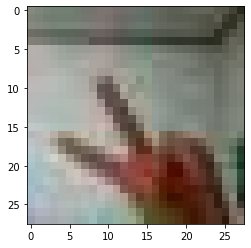

In [23]:
plt.imshow(x_test[0])
print('라벨: ', y_test[0])

# Model Test

In [21]:
# model을 학습시키는 코드를 직접 작성해 보세요.
# Hint! model.evaluate()을 사용해 봅시다.
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2)

print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 0s - loss: 3.7475 - accuracy: 0.3300
test_loss: 3.747525215148926 
test_accuracy: 0.33000001311302185


# 모델 성능 개선하기!

In [59]:
# 정규화 데이터 그대로 사용
"""
x_train_norm : 이미지 데이터를 0~255 정수 값을 0~1로 정규화,
float32로 맞춰 모델이 학습하기 쉬운 형태로 변환했음.
(딥러닝 연산은 보통 float32를 표준으로 씀.)
"""
x_train = x_train_norm.astype(np.float32)
x_test  = x_test_norm.astype(np.float32)

n_channel_1=16
n_channel_2=32
n_dense=32
n_train_epoch=30  # 에폭 10 -> 30으로 증가

model = keras.models.Sequential([
    # input 형태 : 28x28x3 -> 28x28 크기의 컬러 이미지 (RGB3채널)
    keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,3)),
    keras.layers.MaxPool2D(2,2),
    keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(n_dense, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

In [60]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=n_train_epoch, batch_size=32, verbose=1)

Epoch 1/30
10/10 [==============================] - 1s 24ms/step - loss: 1.1168 - accuracy: 0.3067
Epoch 2/30
10/10 [==============================] - 0s 24ms/step - loss: 1.1003 - accuracy: 0.3300
Epoch 3/30
10/10 [==============================] - 0s 29ms/step - loss: 1.0976 - accuracy: 0.3367
Epoch 4/30
10/10 [==============================] - 0s 23ms/step - loss: 1.0932 - accuracy: 0.3900
Epoch 5/30
10/10 [==============================] - 0s 23ms/step - loss: 1.0904 - accuracy: 0.4433
Epoch 6/30
10/10 [==============================] - 0s 24ms/step - loss: 1.0882 - accuracy: 0.4100
Epoch 7/30
10/10 [==============================] - 0s 25ms/step - loss: 1.0853 - accuracy: 0.4033
Epoch 8/30
10/10 [==============================] - 0s 27ms/step - loss: 1.0803 - accuracy: 0.4000
Epoch 9/30
10/10 [==============================] - 0s 23ms/step - loss: 1.0782 - accuracy: 0.4433
Epoch 10/30
10/10 [==============================] - 0s 26ms/step - loss: 1.0751 - accuracy: 0.4100
Epoch 11/

In [61]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("test_loss:", test_loss)
print("test_acc:", test_acc)

10/10 - 0s - loss: 1.0624 - accuracy: 0.4367
test_loss: 1.0623894929885864
test_acc: 0.43666666746139526
